<a href="https://colab.research.google.com/github/danielarriaga260-ai/Actividades/blob/main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AF8 Redes Neuronales Convolusionales  N5 LMV**

René David Hernández Canizales 2121097

Daniel Alejandro Arriaga Durán 2121525

Diego Luna Bautista 2097159

Juan Enrique Silva Chávez 2094297

Joshua De La Mora Ramos 2082407


**Importar librerias a utilizar**

In [15]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

**Cargamos nuestro dataset y normalizamos los datos**

In [5]:
tf.keras.datasets.mnist.load_data(path="mnist.npz")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [8]:
x_train=x_train/255.0
x_test=x_test/255.0

Generamos nuestras etiquetas

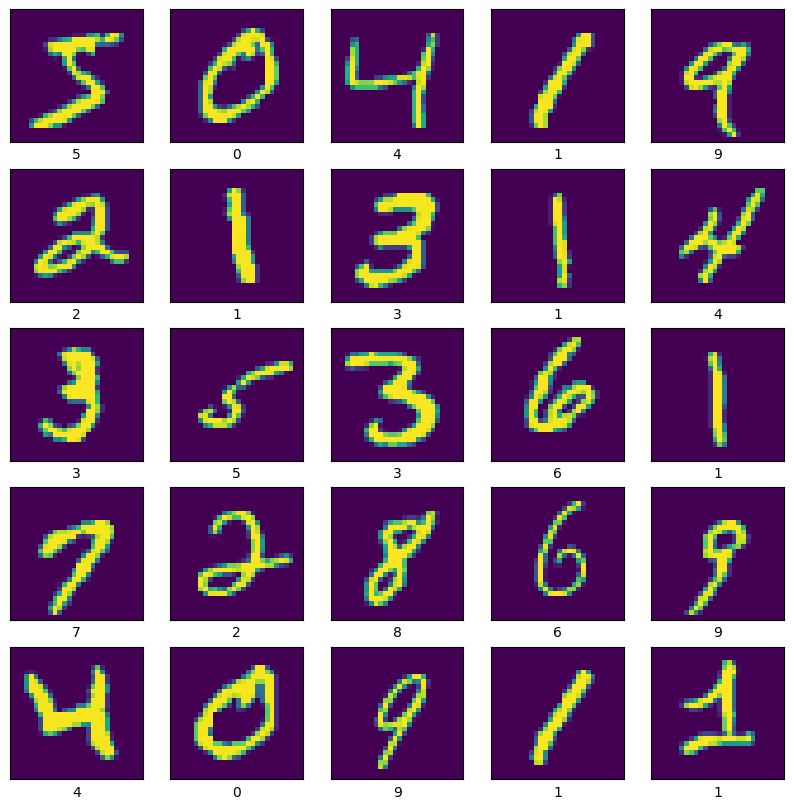

In [9]:
class_names=['0','1','2','3','4','5','6','7','8','9']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

Base convolucional

In [10]:
# Reshape to add channel dimension (28, 28) -> (28, 28, 1)
x_train_reshaped = tf.expand_dims(x_train, axis=-1)
x_test_reshaped = tf.expand_dims(x_test, axis=-1)

# Pad from 28x28 to 32x32 (padding 2 pixels on each side)
x_train_padded = tf.image.pad_to_bounding_box(x_train_reshaped, 2, 2, 32, 32)
x_test_padded = tf.image.pad_to_bounding_box(x_test_reshaped, 2, 2, 32, 32)

# Convert grayscale (1 channel) to RGB (3 channels) by duplicating
x_train_processed = tf.image.grayscale_to_rgb(x_train_padded)
x_test_processed = tf.image.grayscale_to_rgb(x_test_padded)


In [11]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**Compilar y entrenar al modelo**

In [12]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train_processed, y_train, epochs=10,
                    validation_data=(x_test_processed, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 45ms/step - accuracy: 0.9602 - loss: 0.1283 - val_accuracy: 0.9840 - val_loss: 0.0514
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.9865 - loss: 0.0422 - val_accuracy: 0.9899 - val_loss: 0.0300
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.9911 - loss: 0.0293 - val_accuracy: 0.9910 - val_loss: 0.0290
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9930 - loss: 0.0220 - val_accuracy: 0.9898 - val_loss: 0.0347
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.9939 - loss: 0.0186 - val_accuracy: 0.9912 - val_loss: 0.0318
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.9887 - val_loss: 0.0428
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accuracy: 0.9920 - val_loss: 0.0283
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9963 -

313/313 - 4s - 12ms/step - accuracy: 0.9896 - loss: 0.0415


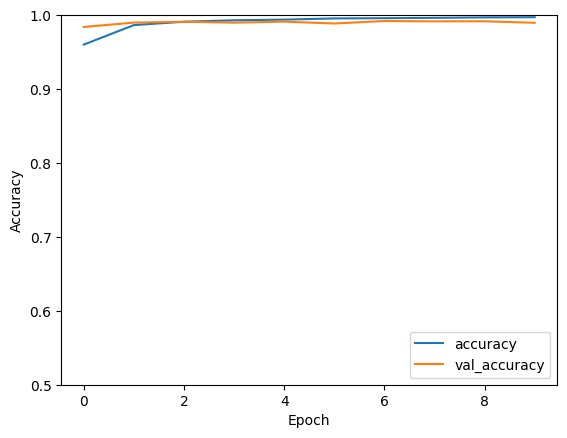

In [13]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test_processed,  y_test, verbose=2)

**Predicciones del Modelo**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


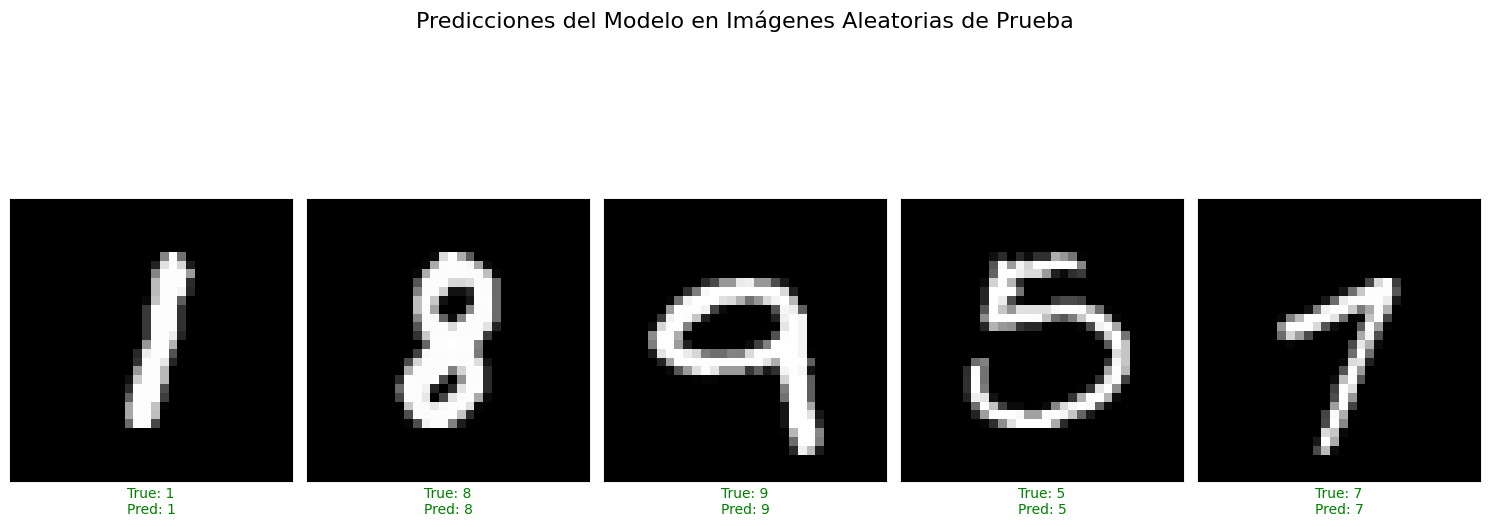

In [14]:
import numpy as np
import tensorflow as tf

# Seleccionar 5 índices aleatorios del conjunto de prueba
num_predictions = 5
r_indices = np.random.choice(x_test_processed.shape[0], num_predictions, replace=False)

# Obtener las imágenes, etiquetas reales y hacer predicciones
r_test_images = tf.gather(x_test_processed, r_indices) # Usar tf.gather para indexar el tensor
r_true_labels = y_test[r_indices]
r_predictions = model.predict(r_test_images)

plt.figure(figsize=(15, 6))
for i in range(num_predictions):
    plt.subplot(1, num_predictions, i + 1)
    plt.imshow(r_test_images[i].numpy()) # Convertir a NumPy para imshow
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    predicted_label = np.argmax(r_predictions[i])
    true_label = r_true_labels[i]

    color = 'green' if predicted_label == true_label else 'red'
    plt.xlabel(f'True: {class_names[true_label]}\nPred: {class_names[predicted_label]}', color=color)

plt.suptitle('Predicciones del Modelo en Imágenes Aleatorias de Prueba', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()